In [57]:
from google.colab import files
files.upload()


Saving day.csv to day (1).csv
Saving hour.csv to hour (1).csv


{'day (1).csv': b'instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt\r\n1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985\r\n2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801\r\n3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349\r\n4,2011-01-04,1,0,1,0,2,1,1,0.2,0.212122,0.590435,0.160296,108,1454,1562\r\n5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.22927,0.436957,0.1869,82,1518,1600\r\n6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.0895652,88,1518,1606\r\n7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510\r\n8,2011-01-08,1,0,1,0,6,0,2,0.165,0.162254,0.535833,0.266804,68,891,959\r\n9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.36195,54,768,822\r\n10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321\r\n11,2011-01-11,1,0,1,0,2,1,2,0.169091,0.191464,0.686364,0.122132,43,1220,1263\r\n12,2011

In [58]:
import pandas as pd

day = pd.read_csv("day.csv")
hour = pd.read_csv("hour.csv")

day.head(), hour.head()


(   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
 0        1  2011-01-01       1   0     1        0        6           0   
 1        2  2011-01-02       1   0     1        0        0           0   
 2        3  2011-01-03       1   0     1        0        1           1   
 3        4  2011-01-04       1   0     1        0        2           1   
 4        5  2011-01-05       1   0     1        0        3           1   
 
    weathersit      temp     atemp       hum  windspeed  casual  registered  \
 0           2  0.344167  0.363625  0.805833   0.160446     331         654   
 1           2  0.363478  0.353739  0.696087   0.248539     131         670   
 2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
 3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
 4           1  0.226957  0.229270  0.436957   0.186900      82        1518   
 
     cnt  
 0   985  
 1   801  
 2  1349  
 3  1562  
 4  1600  ,
    i

In [59]:
# shapes and infor

print(day.shape)
print(hour.shape)
# Hourly data is much larger → more patterns

(731, 16)
(17379, 17)


In [60]:
day.info()
hour.info()

# Confirms no missing values
# Confirms data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

In [61]:
# Data Quality Check (Trust the Data)
day.isnull().sum()
hour.isnull().sum()


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [62]:
# Duplicate Records
day.duplicated().sum(), hour.duplicated().sum()


(np.int64(0), np.int64(0))

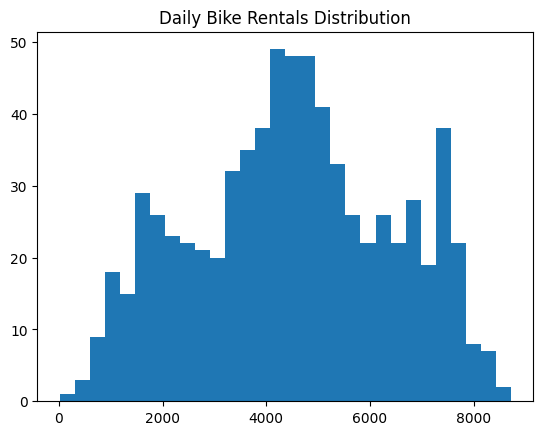

In [63]:
# Target Distribution
import matplotlib.pyplot as plt

plt.hist(day['cnt'], bins=30)
plt.title("Daily Bike Rentals Distribution")
plt.show()
# Right-skewed distribution
# ➡️ Suggests log transform later

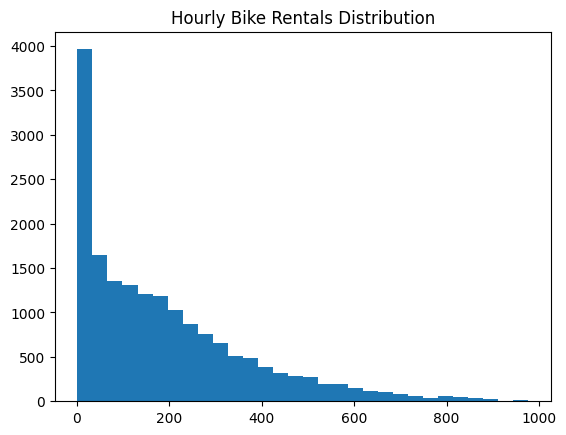

In [64]:
plt.hist(hour['cnt'], bins=30)
plt.title("Hourly Bike Rentals Distribution")
plt.show()
# Right-skewed distribution
# ➡️ Suggests log transform later

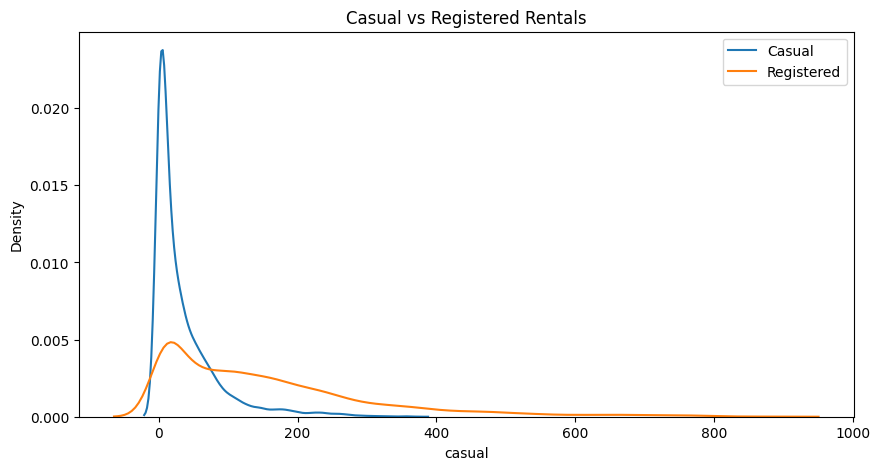

In [65]:
# Casual vs Registered Users
import seaborn as sns
plt.figure(figsize=(10,5))
sns.kdeplot(hour['casual'], label="Casual")
sns.kdeplot(hour['registered'], label="Registered")
plt.legend()
plt.title("Casual vs Registered Rentals")
plt.show()


Time-Based Analysis

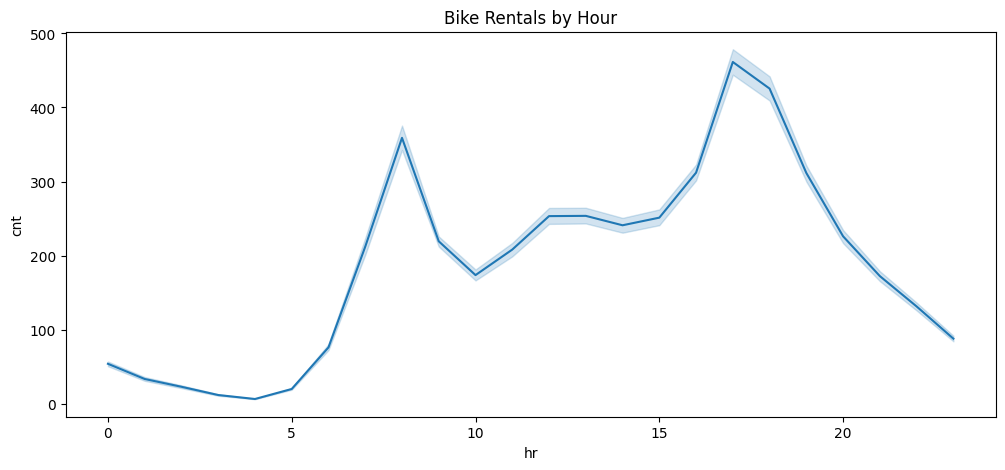

In [66]:

# Hourly Demand Pattern
plt.figure(figsize=(12,5))
sns.lineplot(x='hr', y='cnt', data=hour)
plt.title("Bike Rentals by Hour")
plt.show()


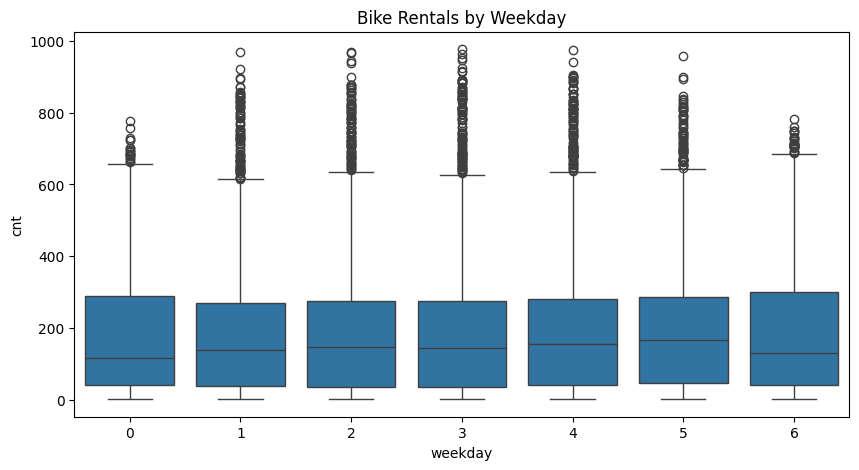

In [67]:
# Daily Pattern (Weekday vs Weekend)
plt.figure(figsize=(10,5))
sns.boxplot(x='weekday', y='cnt', data=hour)
plt.title("Bike Rentals by Weekday")
plt.show()


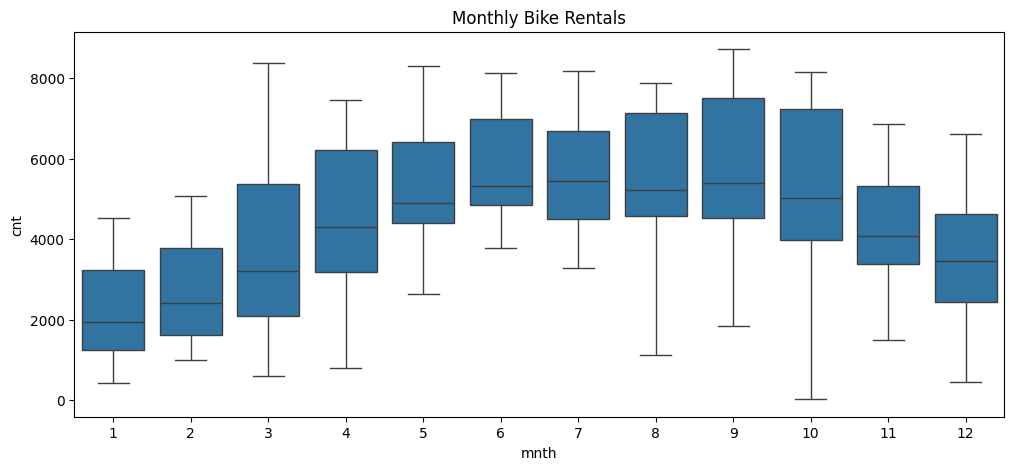

In [68]:
# Monthly & Seasonal Trends
plt.figure(figsize=(12,5))
sns.boxplot(x='mnth', y='cnt', data=day)
plt.title("Monthly Bike Rentals")
plt.show()


Weather Impact Analysis

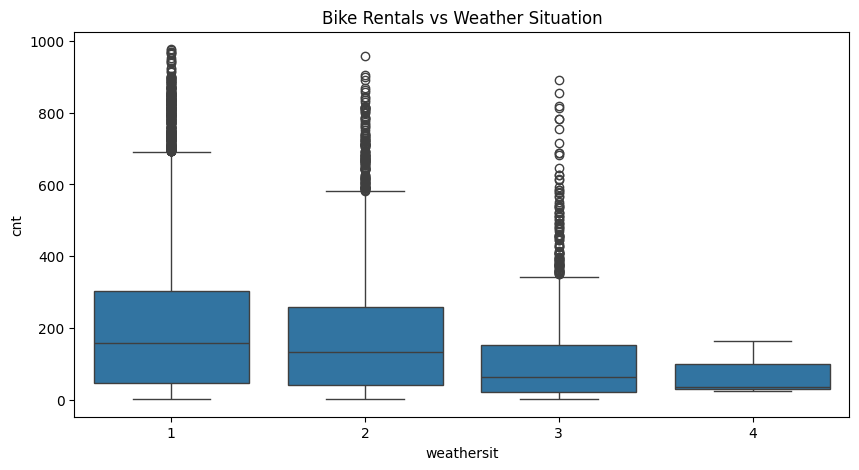

In [69]:
# Weather Situation vs Rentals
plt.figure(figsize=(10,5))
sns.boxplot(x='weathersit', y='cnt', data=hour)
plt.title("Bike Rentals vs Weather Situation")
plt.show()


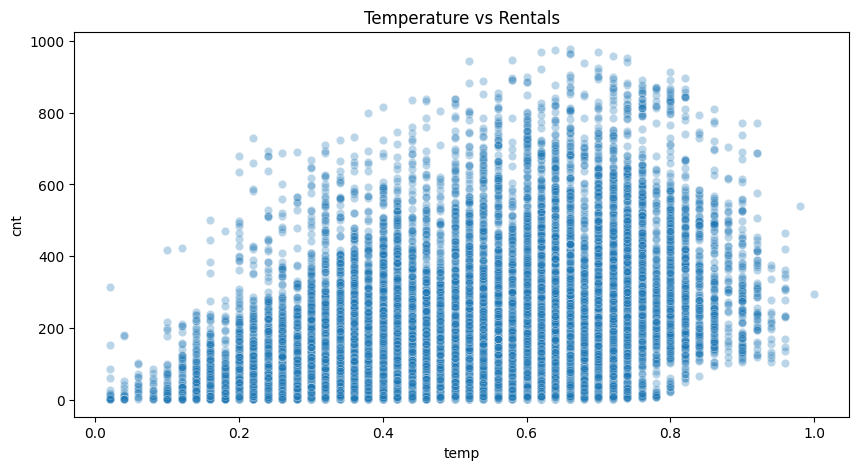

In [70]:
# Temperature Effect
plt.figure(figsize=(10,5))
sns.scatterplot(x='temp', y='cnt', data=hour, alpha=0.3)
plt.title("Temperature vs Rentals")
plt.show()


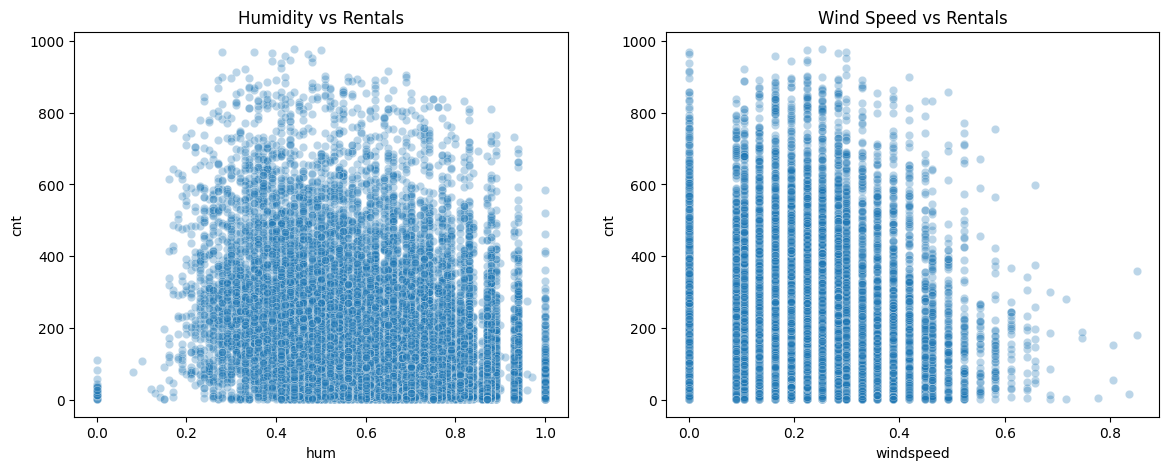

In [71]:
# Humidity & Wind Speed
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.scatterplot(x='hum', y='cnt', data=hour, ax=ax[0], alpha=0.3)
ax[0].set_title("Humidity vs Rentals")

sns.scatterplot(x='windspeed', y='cnt', data=hour, ax=ax[1], alpha=0.3)
ax[1].set_title("Wind Speed vs Rentals")

plt.show()


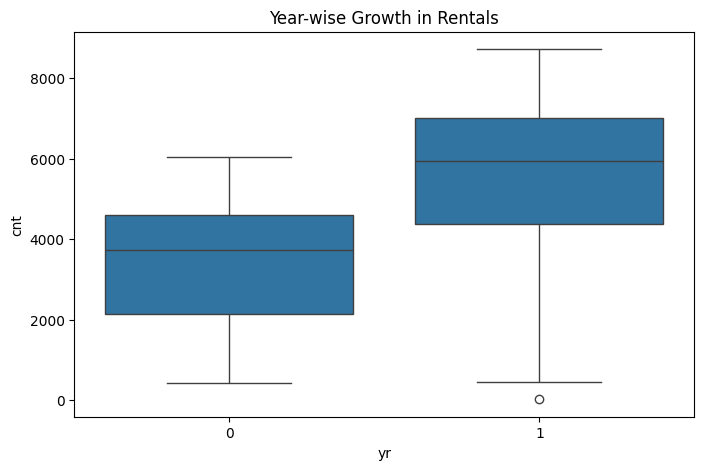

In [72]:
# Yearly Growth Trend
plt.figure(figsize=(8,5))
sns.boxplot(x='yr', y='cnt', data=day)
plt.title("Year-wise Growth in Rentals")
plt.show()

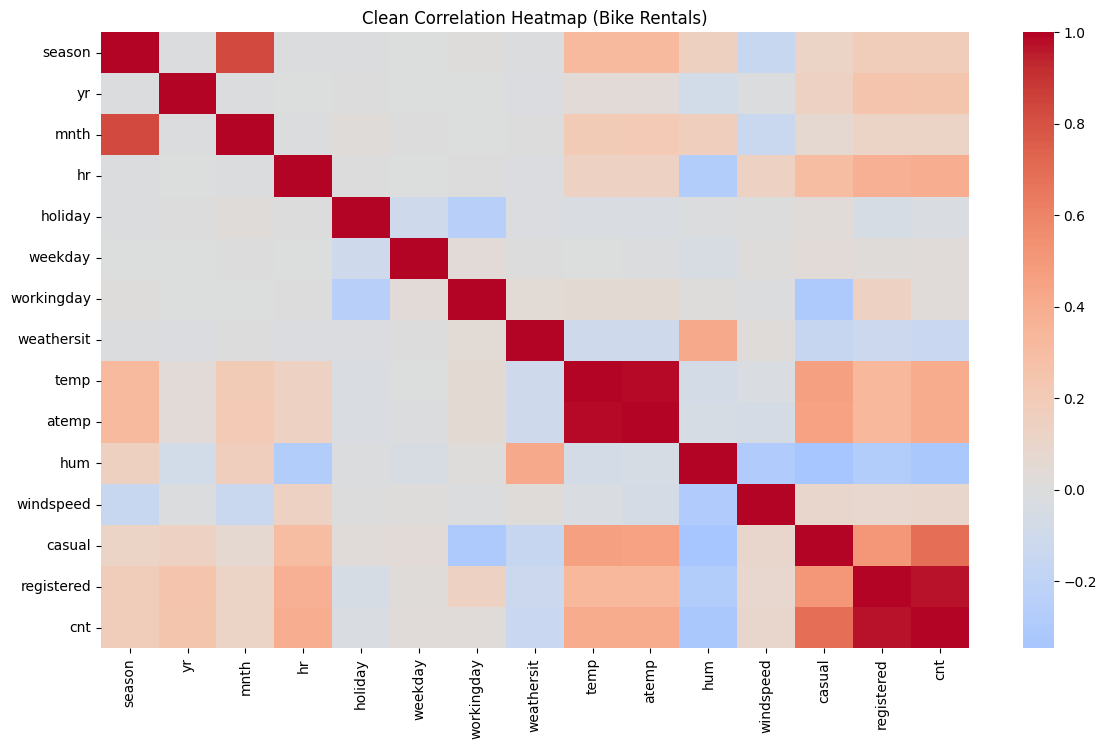

In [73]:
corr_data = hour.drop(columns=['dteday', 'instant'])
corr_data = corr_data.select_dtypes('number')

plt.figure(figsize=(14,8))
sns.heatmap(corr_data.corr(), cmap="coolwarm", center=0)
plt.title("Clean Correlation Heatmap (Bike Rentals)")
plt.show()


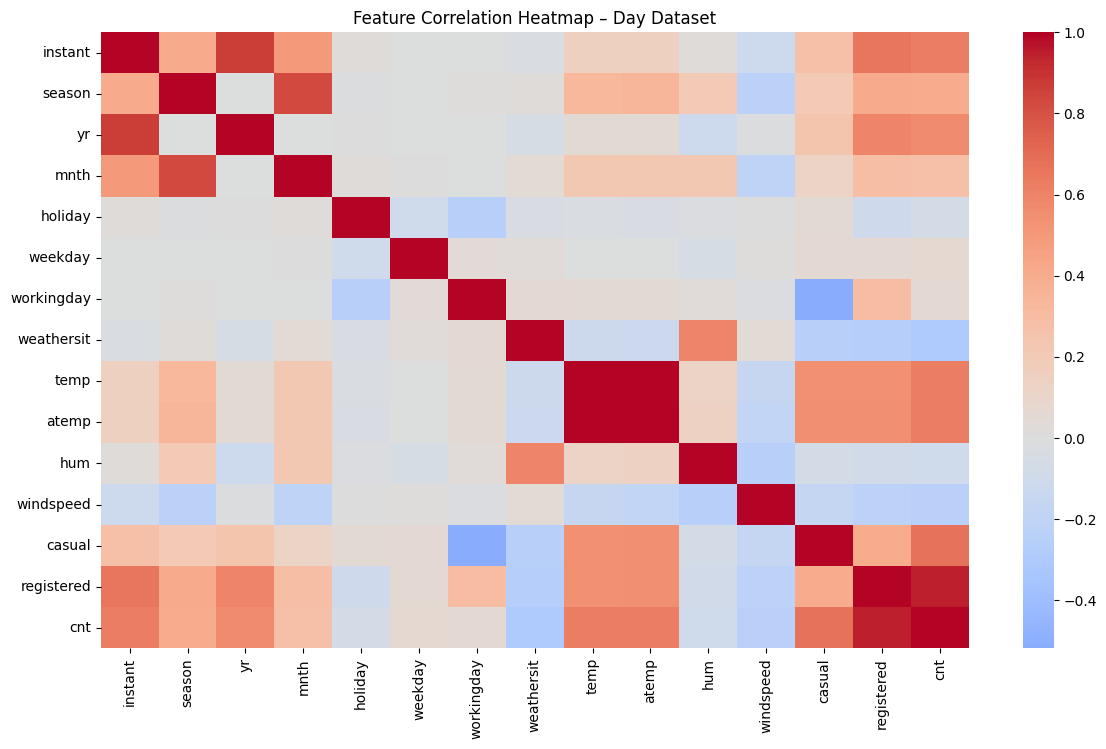

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
numeric_day = day.select_dtypes(include=[np.number])

plt.figure(figsize=(14,8))
sns.heatmap(
    numeric_day.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap – Day Dataset")
plt.show()


| Feature    | Effect        |
| ---------- | ------------- |
| temp       | Strong +      |
| atemp      | Strong +      |
| hum        | Negative      |
| windspeed  | Negative      |
| registered | Very strong + |


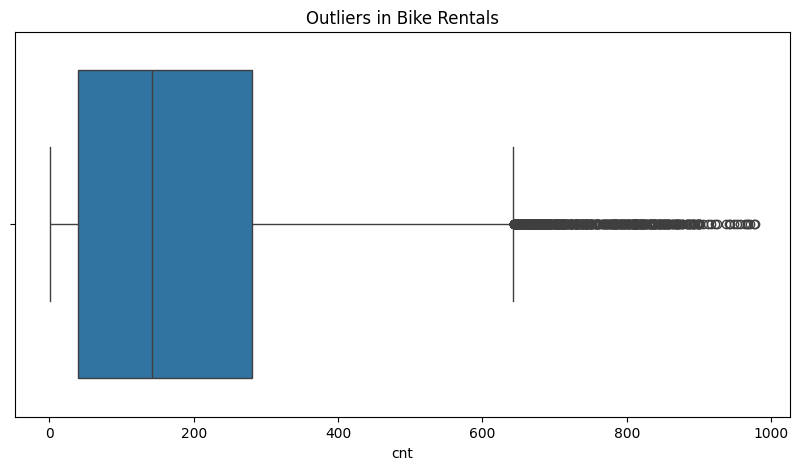

In [75]:
# Outlier Analysis
plt.figure(figsize=(10,5))
sns.boxplot(x=hour['cnt'])
plt.title("Outliers in Bike Rentals")
plt.show()


# Feature Engineering for Bike Rental Prediction

In [76]:
# Combine Both Datasets
import pandas as pd
import numpy as np

day['source'] = 'day'
hour['source'] = 'hour'

df = pd.concat([hour, day], ignore_index=True)
df['dteday'] = pd.to_datetime(df['dteday'])

print(df.shape)
df.head()

(18110, 18)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,source
0,1,2011-01-01,1,0,1,0.0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,hour
1,2,2011-01-01,1,0,1,1.0,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,hour
2,3,2011-01-01,1,0,1,2.0,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,hour
3,4,2011-01-01,1,0,1,3.0,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,hour
4,5,2011-01-01,1,0,1,4.0,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,hour


Feature Group 1: Date decomposition

In [77]:
# Helps model learn weekly & yearly cycles
# Strongly improves seasonal prediction

df['dteday'] = pd.to_datetime(df['dteday'])

df['dayofweek'] = df['dteday'].dt.dayofweek   # 0=Mon
df['weekofyear'] = df['dteday'].dt.isocalendar().week
df['dayofyear'] = df['dteday'].dt.dayofyear

df[['dteday','dayofweek','weekofyear','dayofyear']].head(10)

,dteday,dayofweek,weekofyear,dayofyear
0,2011-01-01,5,52,1
1,2011-01-01,5,52,1
2,2011-01-01,5,52,1
3,2011-01-01,5,52,1
4,2011-01-01,5,52,1
5,2011-01-01,5,52,1
6,2011-01-01,5,52,1
7,2011-01-01,5,52,1
8,2011-01-01,5,52,1
9,2011-01-01,5,52,1


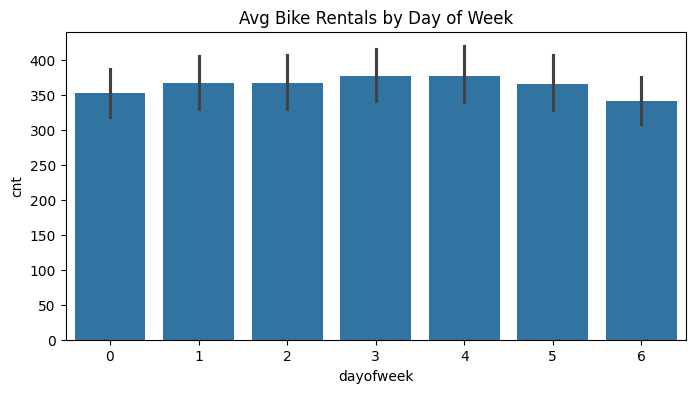

In [78]:
plt.figure(figsize=(8,4))
sns.barplot(x='dayofweek', y='cnt', data=df)
plt.title("Avg Bike Rentals by Day of Week")
plt.show()


Weekend & Working Behavior Features
🔹 Feature Group 2: Human routine encoding

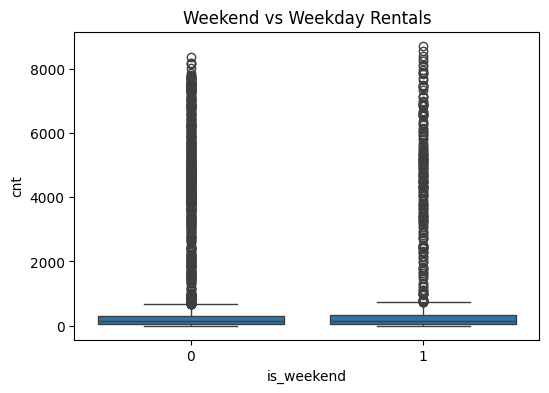

In [79]:
df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)
df['is_workingday'] = ((df['workingday'] == 1) & (df['holiday'] == 0)).astype(int)

plt.figure(figsize=(6,4))
sns.boxplot(x='is_weekend', y='cnt', data=df)
plt.title("Weekend vs Weekday Rentals")
plt.show()


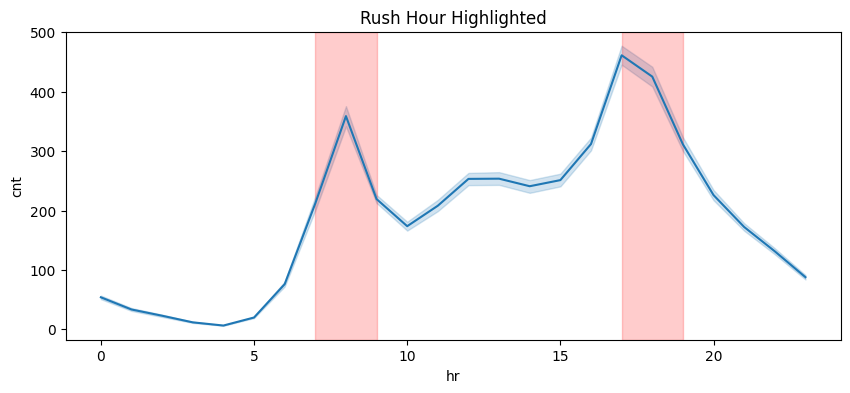

In [80]:
# Hour-based Behavioral Features (from EDA)
# 🔹 Feature Group 3: Daily activity rhythm
# EDA clearly showed rush-hour peaks
df['is_rush_hour'] = (
    (df['hr'].between(7,9)) | (df['hr'].between(17,19))
).astype(int)

df['is_night'] = ((df['hr'] >= 22) | (df['hr'] <= 5)).astype(int)

plt.figure(figsize=(10,4))
sns.lineplot(x='hr', y='cnt', data=df)
plt.axvspan(7,9, color='red', alpha=0.2)
plt.axvspan(17,19, color='red', alpha=0.2)
plt.title("Rush Hour Highlighted")
plt.show()



Weather Interaction Features (Comfort Index)

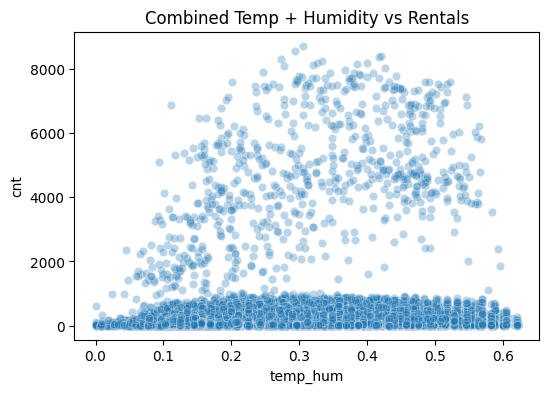

In [81]:
df['temp_diff'] = df['temp'] - df['atemp']
df['temp_hum'] = df['temp'] * df['hum']

df[['temp','atemp','temp_diff','hum','temp_hum']].head()
plt.figure(figsize=(6,4))
sns.scatterplot(x='temp_hum', y='cnt', data=df, alpha=0.3)
plt.title("Combined Temp + Humidity vs Rentals")
plt.show()


In [82]:
# Raw month problem
df.groupby('mnth')['cnt'].mean()


,cnt
mnth,
1,180.996647
2,216.526466
3,298.267101
4,359.511022
5,427.981935
6,461.789333
7,445.094194
8,456.986337
9,462.245825


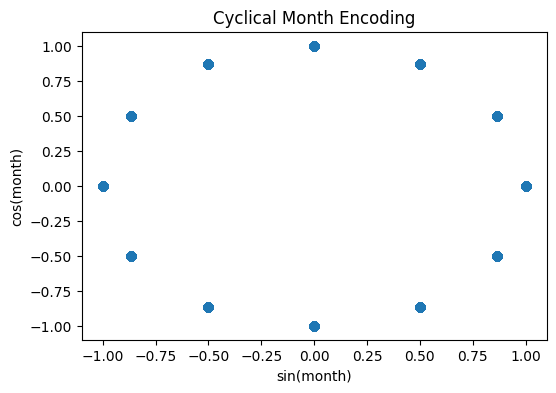

In [83]:
# Cyclical encoding
df['mnth_sin'] = np.sin(2*np.pi*df['mnth']/12)
df['mnth_cos'] = np.cos(2*np.pi*df['mnth']/12)

df[['mnth','mnth_sin','mnth_cos']].drop_duplicates().head(12)
plt.figure(figsize=(6,4))
plt.scatter(df['mnth_sin'], df['mnth_cos'], alpha=0.3)
plt.title("Cyclical Month Encoding")
plt.xlabel("sin(month)")
plt.ylabel("cos(month)")
plt.show()


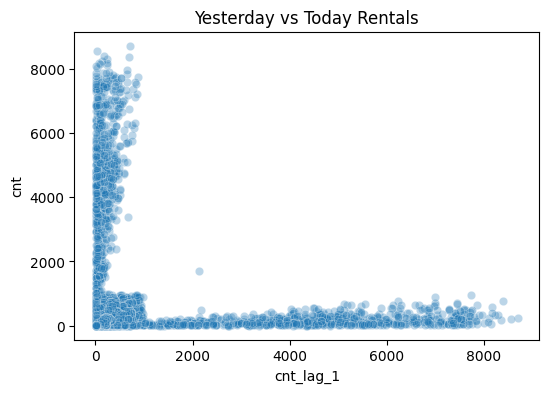

In [84]:
# Lag Features (TEXT + VISUAL PROOF)
df = df.sort_values('dteday')
df['cnt_lag_1'] = df['cnt'].shift(1)

df[['dteday','cnt','cnt_lag_1']].head(10)
plt.figure(figsize=(6,4))
sns.scatterplot(x='cnt_lag_1', y='cnt', data=df, alpha=0.3)
plt.title("Yesterday vs Today Rentals")
plt.show()


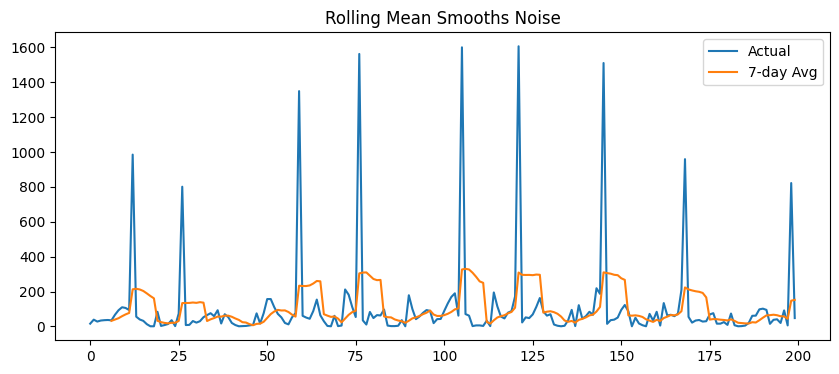

In [85]:
# Rolling Mean Feature (TREND CAPTURE)
df['cnt_roll_7'] = df['cnt'].rolling(7).mean()

df[['cnt','cnt_roll_7']].head(10)
plt.figure(figsize=(10,4))
plt.plot(df['cnt'].values[:200], label='Actual')
plt.plot(df['cnt_roll_7'].values[:200], label='7-day Avg')
plt.legend()
plt.title("Rolling Mean Smooths Noise")
plt.show()


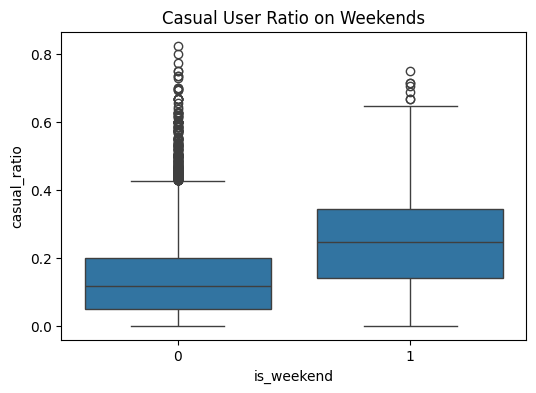

In [86]:
# User Ratio Features (CLEAR OUTPUT)
df['casual_ratio'] = df['casual'] / (df['cnt'] + 1)
df['registered_ratio'] = df['registered'] / (df['cnt'] + 1)

df[['casual','registered','cnt','casual_ratio','registered_ratio']].head()
plt.figure(figsize=(6,4))
sns.boxplot(x='is_weekend', y='casual_ratio', data=df)
plt.title("Casual User Ratio on Weekends")
plt.show()


In [87]:
# Final Feature Summary (VISIBLE)
df_model = df.dropna()

print("Final feature count:", df_model.shape[1])
df_model.head(3)


Final feature count: 33


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,is_rush_hour,is_night,temp_diff,temp_hum,mnth_sin,mnth_cos,cnt_lag_1,cnt_roll_7,casual_ratio,registered_ratio
18,19,2011-01-01,1,0,1,18.0,0,6,0,3,...,1,0,-0.0042,0.3696,0.5,0.866025,37.0,32.142857,0.250000,0.722222
17,18,2011-01-01,1,0,1,17.0,0,6,0,2,...,1,0,0.0006,0.3608,0.5,0.866025,35.0,39.428571,0.220588,0.764706
16,17,2011-01-01,1,0,1,16.0,0,6,0,2,...,0,0,-0.0042,0.3444,0.5,0.866025,67.0,47.142857,0.436170,0.553191


# Bike Rental Prediction – Model Training (Multi-Algorithm)

In [90]:
df_model['temp_wind'] = df_model['temp'] * df_model['windspeed']

print(df.columns.tolist())


['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'source', 'dayofweek', 'weekofyear', 'dayofyear', 'is_weekend', 'is_workingday', 'is_rush_hour', 'is_night', 'temp_diff', 'temp_hum', 'mnth_sin', 'mnth_cos', 'cnt_lag_1', 'cnt_roll_7', 'casual_ratio', 'registered_ratio']


/tmp/ipython-input-3534859092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['temp_wind'] = df_model['temp'] * df_model['windspeed']


# Final Dataset for Training

In [91]:
from sklearn.model_selection import train_test_split
import numpy as np

features = [
    'season','yr','holiday','workingday','weathersit',
    'temp','atemp','hum','windspeed',
    'hr',
    'dayofweek','weekofyear','dayofyear',
    'is_weekend','is_rush_hour','is_night',
    'temp_diff','temp_hum','temp_wind',
    'mnth_sin','mnth_cos',
    'cnt_lag_1','cnt_roll_7'
]

# Target
y = np.log1p(df_model['cnt'])

# ✅ CORRECT FEATURE MATRIX
X = df_model[features]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(13898, 23) (3475, 23)


| # | Algorithm         | Why this algorithm?       |
| - | ----------------- | ------------------------- |
| 1 | Linear Regression | Baseline                  |
| 2 | Ridge Regression  | Handles multicollinearity |
| 3 | Lasso Regression  | Feature selection         |
| 4 | Random Forest     | Captures non-linearity    |
| 5 | Gradient Boosting | Learns complex patterns   |
| 6 | XGBoost           | Best for tabular data     |


In [92]:
# Model Evaluation Function
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(name, model):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-"*30)
    return rmse, r2


In [93]:
# Linear Regression (Baseline)
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

evaluate_model("Linear Regression", lr)


Linear Regression
RMSE : 0.7282
R²   : 0.7371
------------------------------


(np.float64(0.7281607833530608), 0.7371294229020502)

In [94]:
# Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

evaluate_model("Ridge Regression", ridge)
# Better stability than linear regression

Ridge Regression
RMSE : 0.7281
R²   : 0.7372
------------------------------


(np.float64(0.7281234029317925), 0.7371564113389981)

In [95]:
# Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.001)
lasso.fit(X_train, y_train)

evaluate_model("Lasso Regression", lasso)


Lasso Regression
RMSE : 0.7289
R²   : 0.7366
------------------------------


(np.float64(0.7289371796654378), 0.736568556244427)

In [96]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

evaluate_model("Random Forest", rf)


Random Forest
RMSE : 0.3256
R²   : 0.9474
------------------------------


(np.float64(0.32558259458451405), 0.9474455170920252)

In [97]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

evaluate_model("Gradient Boosting", gbr)


Gradient Boosting
RMSE : 0.4027
R²   : 0.9196
------------------------------


(np.float64(0.40273797322181143), 0.9195858328846749)

In [98]:
# XGBoost (BEST MODEL)
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate_model("XGBoost", xgb)


XGBoost
RMSE : 0.2803
R²   : 0.9610
------------------------------


(np.float64(0.28032833553969183), 0.9610397796387238)

In [99]:
# Model Comparison (TEXT + TABLE)
results = []

models = {
    "Linear": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb
}

for name, model in models.items():
    rmse, r2 = evaluate_model(name, model)
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model","RMSE","R2"])
results_df.sort_values("R2", ascending=False)


Linear
RMSE : 0.7282
R²   : 0.7371
------------------------------
Ridge
RMSE : 0.7281
R²   : 0.7372
------------------------------
Lasso
RMSE : 0.7289
R²   : 0.7366
------------------------------
Random Forest
RMSE : 0.3256
R²   : 0.9474
------------------------------
Gradient Boosting
RMSE : 0.4027
R²   : 0.9196
------------------------------
XGBoost
RMSE : 0.2803
R²   : 0.9610
------------------------------


,Model,RMSE,R2
5,XGBoost,0.280328,0.961040
3,Random Forest,0.325583,0.947446
4,Gradient Boosting,0.402738,0.919586
1,Ridge,0.728123,0.737156
0,Linear,0.728161,0.737129
2,Lasso,0.728937,0.736569


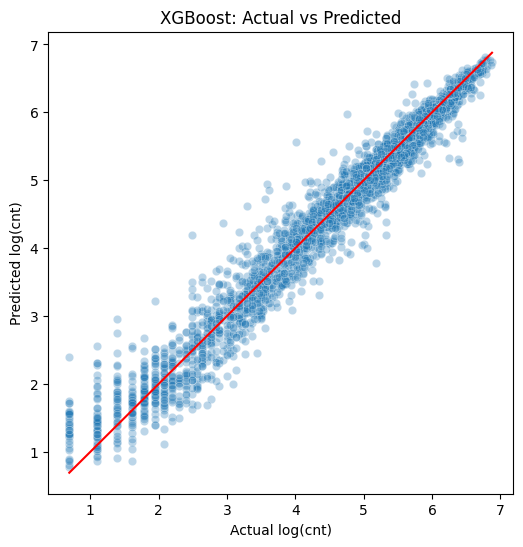

In [100]:
# Visual Proof – Prediction vs Actual
preds = xgb.predict(X_test)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=preds, alpha=0.3)
plt.xlabel("Actual log(cnt)")
plt.ylabel("Predicted log(cnt)")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")
plt.show()


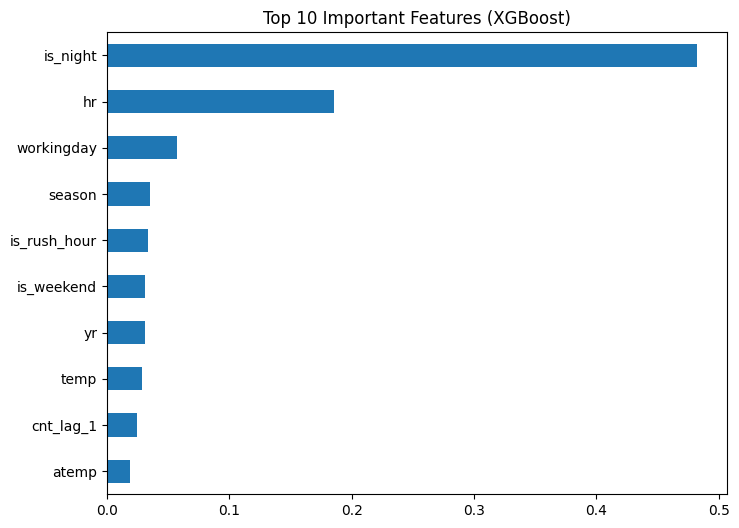

In [101]:
# Feature Importance (VISUAL PROOF)
importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(10).plot(kind='barh')
plt.title("Top 10 Important Features (XGBoost)")
plt.gca().invert_yaxis()
plt.show()


In [102]:
# ElasticNet (NEW – Recommended)
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=0.001, l1_ratio=0.5)
elastic.fit(X_train, y_train)
evaluate_model("ElasticNet", elastic)


ElasticNet
RMSE : 0.7284
R²   : 0.7369
------------------------------


(np.float64(0.7284113209685202), 0.73694850050391)

In [104]:
# LightGBM
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm.fit(X_train, y_train)
evaluate_model("LightGBM", lgbm)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000911 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1818
[LightGBM] [Info] Number of data points in the train set: 13898, number of used features: 23
[LightGBM] [Info] Start training from score 4.575987
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

(np.float64(0.2857209311976723), 0.9595264292325139)

In [107]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.8 MB/s eta 0:00:00


In [108]:
# CatBoost Regressor (EXCELLENT)
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    verbose=False
)

cat.fit(X_train, y_train)
evaluate_model("CatBoost", cat)


CatBoost
RMSE : 0.2916
R²   : 0.9579
------------------------------


(np.float64(0.2915714819614138), 0.9578519490586681)

In [110]:
results = []

models = {
    "Linear": lr,
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic,
    "Random Forest": rf,
    "Gradient Boosting": gbr,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "CatBoost": cat
}

for name, model in models.items():
    rmse, r2 = evaluate_model(name, model)
    results.append([name, rmse, r2])

import pandas as pd
results_df = pd.DataFrame(results, columns=["Model","RMSE","R2"])
results_df.sort_values("R2", ascending=False)


Linear
RMSE : 0.7282
R²   : 0.7371
------------------------------
Ridge
RMSE : 0.7281
R²   : 0.7372
------------------------------
Lasso
RMSE : 0.7289
R²   : 0.7366
------------------------------
ElasticNet
RMSE : 0.7284
R²   : 0.7369
------------------------------
Random Forest
RMSE : 0.3256
R²   : 0.9474
------------------------------
Gradient Boosting
RMSE : 0.4027
R²   : 0.9196
------------------------------
XGBoost
RMSE : 0.2803
R²   : 0.9610
------------------------------
LightGBM
RMSE : 0.2857
R²   : 0.9595
------------------------------
CatBoost
RMSE : 0.2916
R²   : 0.9579
------------------------------


,Model,RMSE,R2
6,XGBoost,0.280328,0.961040
7,LightGBM,0.285721,0.959526
8,CatBoost,0.291571,0.957852
4,Random Forest,0.325583,0.947446
5,Gradient Boosting,0.402738,0.919586
1,Ridge,0.728123,0.737156
0,Linear,0.728161,0.737129
3,ElasticNet,0.728411,0.736949
2,Lasso,0.728937,0.736569


In [111]:
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model","RMSE","R2"])
results_df.sort_values("R2", ascending=False)

,Model,RMSE,R2
6,XGBoost,0.280328,0.961040
7,LightGBM,0.285721,0.959526
8,CatBoost,0.291571,0.957852
4,Random Forest,0.325583,0.947446
5,Gradient Boosting,0.402738,0.919586
1,Ridge,0.728123,0.737156
0,Linear,0.728161,0.737129
3,ElasticNet,0.728411,0.736949
2,Lasso,0.728937,0.736569


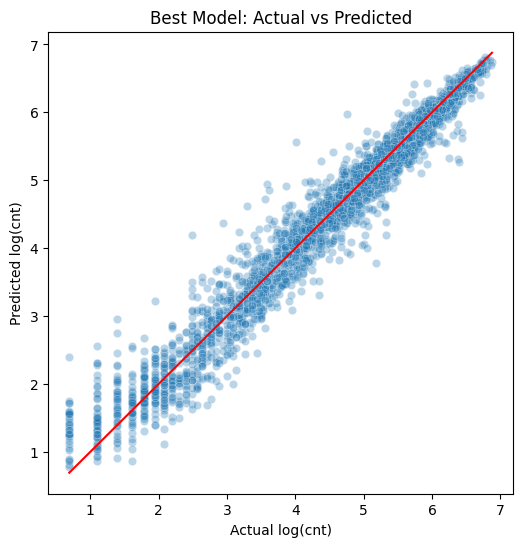

In [112]:
best_model = xgb  # or cat/lgbm based on results
pred = best_model.predict(X_test)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual log(cnt)")
plt.ylabel("Predicted log(cnt)")
plt.title("Best Model: Actual vs Predicted")
plt.show()


| Rank | Model              | Reason           |
| ---- | ------------------ | ---------------- |
| 🥇   | XGBoost / CatBoost | Highest accuracy |
| 🥈   | LightGBM           | Fast + strong    |
| 🥉   | Random Forest      | Stable           |
| ⭐    | ElasticNet         | Interpretable    |